# 04 - Visualization

Assembles the final figures for the thesis/writeup from the outputs of the earlier notebooks. This notebook doesn't recompute anything - it loads the figures already saved to `outputs/figures/` and arranges them for presentation (captions, consistent styling, combined panels).

**Status:** all three source figures now exist - `canon_overlap_graph.png` (01), `translation_lineage_graph.png` (02), and `topic_distribution_by_canon_status.png` (03, added once the processed corpus and LDA topic model were built). This notebook combines all three into one overview panel.

In [1]:
import sys
sys.path.append('../src')

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

FIGURES_DIR = Path('../outputs/figures')

## Canon overlap, translation lineage, and topic distribution, side by side

Each panel comes from a different notebook and a different unit of analysis (canon-level, translation-level, passage-level) - shown together as an overview, not as one integrated figure. If a source figure hasn't been generated yet, its panel shows a placeholder instead of failing the whole notebook.

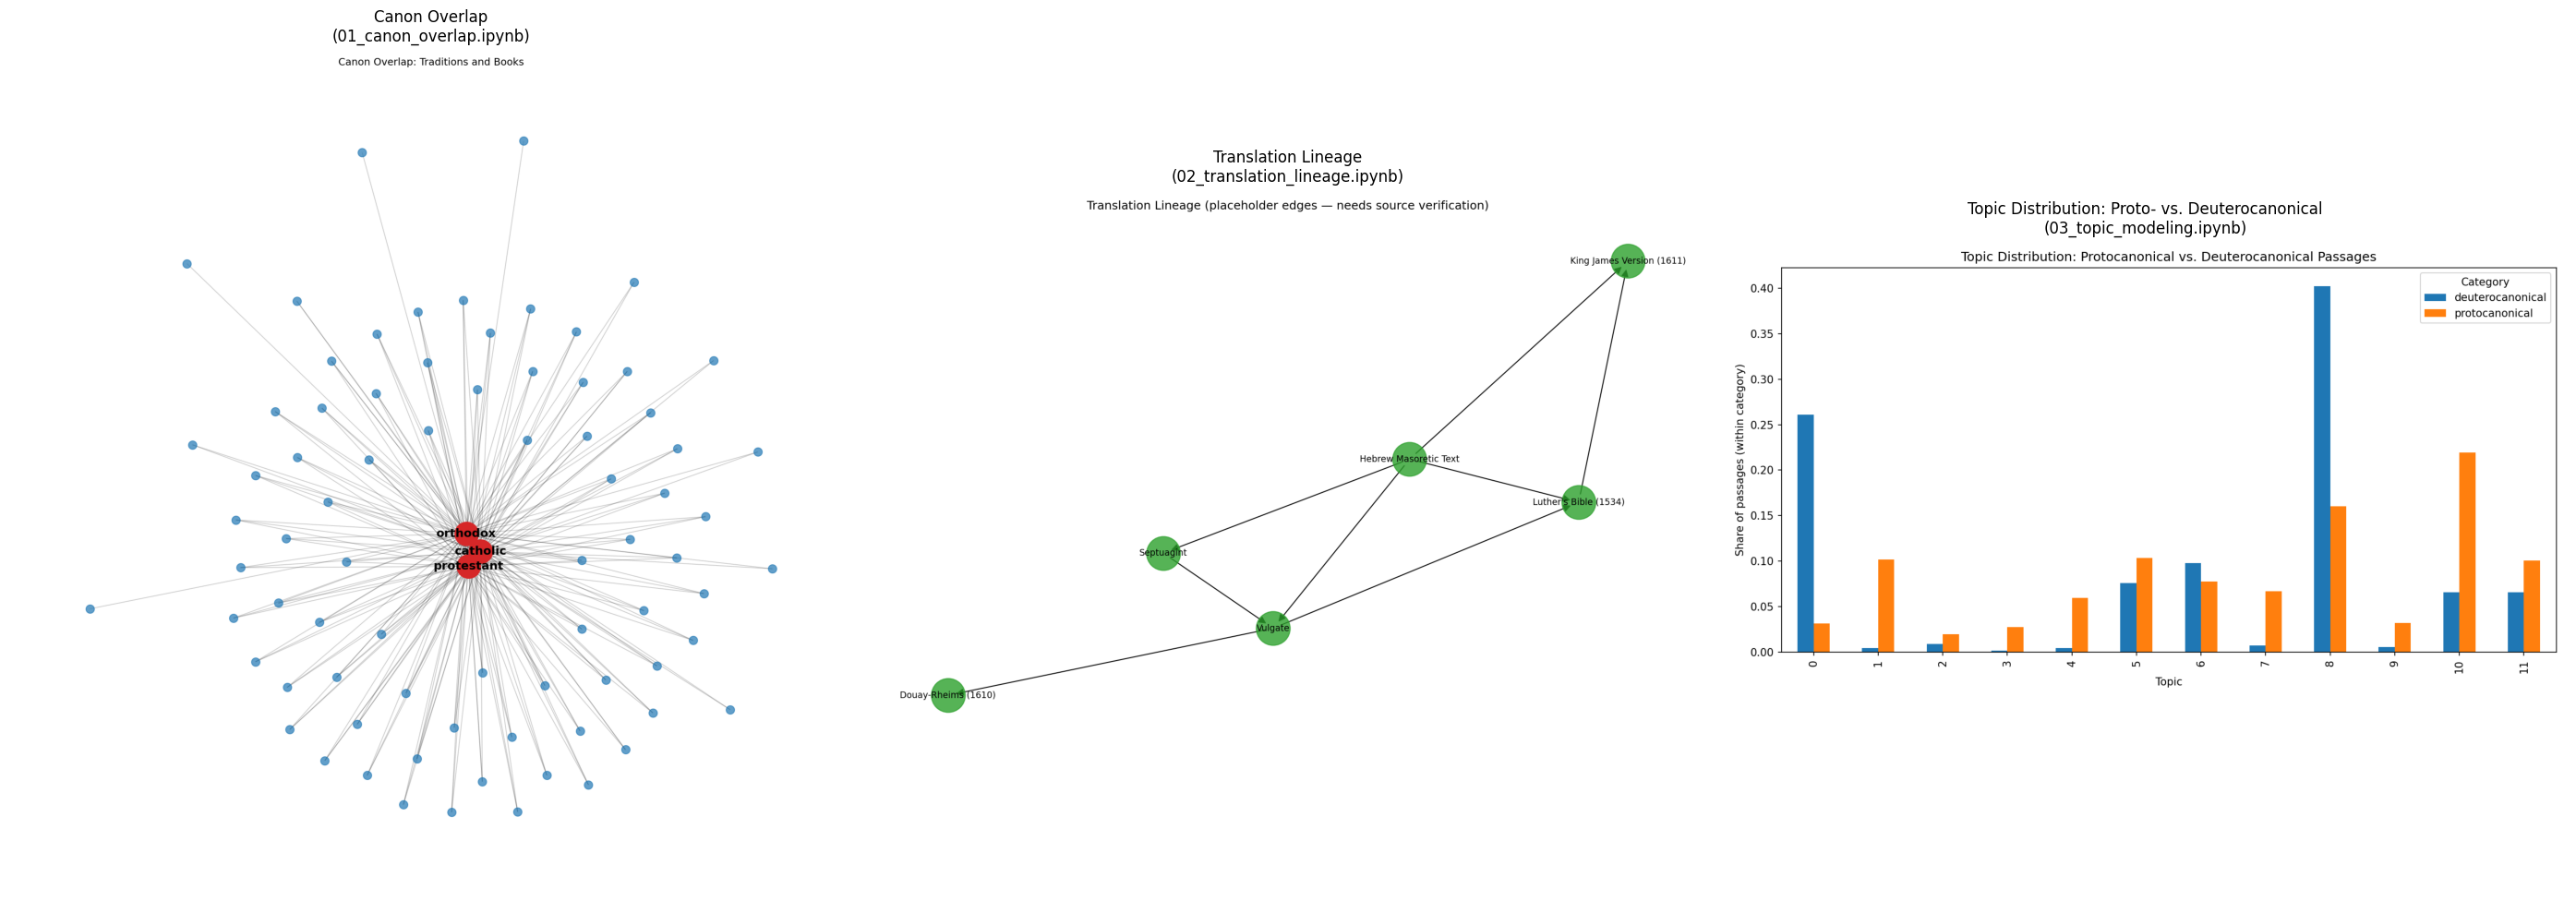

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(28, 10))

panels = [
    ('canon_overlap_graph.png', 'Canon Overlap\n(01_canon_overlap.ipynb)'),
    ('translation_lineage_graph.png', 'Translation Lineage\n(02_translation_lineage.ipynb)'),
    ('topic_distribution_by_canon_status.png', 'Topic Distribution: Proto- vs. Deuterocanonical\n(03_topic_modeling.ipynb)'),
]

for ax, (filename, title) in zip(axes, panels):
    path = FIGURES_DIR / filename
    if not path.exists():
        ax.text(0.5, 0.5, f'Missing: run the notebook that generates\n{filename}',
                ha='center', va='center', wrap=True)
    else:
        ax.imshow(mpimg.imread(path))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'combined_overview.png', dpi=150)
plt.show()

## Notes for the writeup

- **Canon overlap** (panel 1) is the descriptive baseline - Sub-Question 1. Read alongside `data/processed/corpus_manifest.json`'s `canon_overlap_matrix` for the exact per-book presence data.
- **Translation lineage** (panel 2) still uses placeholder edges (`graph_builder.build_translation_lineage_graph` docstring) - cite this figure in the writeup as a structural scaffold, not a sourced claim, until the edges are verified against `docs/historical_notes.md`.
- **Topic distribution** (panel 3) answers Sub-Question 2 with LDA, not BERTopic (see `03_topic_modeling.ipynb` intro cell for why) - note that choice explicitly if this figure goes in the thesis, since topic granularity would likely look different under an embedding-based model.
- All three panels currently draw from different units of analysis (whole canons, translations, ~150-word passages) and aren't meant to be read as one integrated claim - the combined image is a presentation convenience, not a single computed result.